# Battery Current Time Series Model Evaluation

## Import Library

In [1]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, \
    root_mean_squared_error, r2_score
from TimeSeries.src.preprocessing.preprocessing import get_datasets

2026-04-23 04:03:54.605908: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 04:03:54.646399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 04:03:55.782878: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load Test Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_datasets()

Loading:  /home/abel-putra/AndroidMonitoring/Clustering/data/dataset/dataset_time_series.csv
Data Shape:  (124313, 11)
Param Saved
Feature Scaled
Feature Shape:  (124253, 45, 9)
Label Shape:  (124253, 15)
Train Shape:  (74551, 45, 9)
Validation Shape:  (24851, 45, 9)
Test Shape:  (24851, 45, 9)


In [3]:
param_dir = "../data/param/params.json"
with open(param_dir) as f:
    params = json.load(f)

mean_feature = params["mean_feature"]
scale_feature = params["scale_feature"]
mean_target = params["mean_target"]
scale_target = params["scale_target"]
print("Mean Feature: ", mean_feature)
print("Scale Feature: ", scale_feature)
print("Mean Target: ", mean_target)
print("Scale Target: ", scale_target)

Mean Feature:  [46.782605198169136, 71.52006628429851, 31.571077843829688, 43.12609300716739, 0.06691979117228286, 4.9992291768331585, 82.06389909309014, 0.4706265635935099, 21.971595891017028]
Scale Feature:  [19.591367774073447, 4.7082492230010455, 4.726452546469721, 19.730322188692952, 0.24988303808330192, 38.48014327793872, 459.39526374435286, 0.4991364555246129, 2.5515475246186377]
Mean Target:  [-6.6612984965369675]
Scale Target:  [788.8801388757424]


## Load Model

In [4]:
def load_tflite_model(path):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()
    return interpreter

In [5]:
model_rnn = tf.keras.models.load_model('../data/model/RNN.keras')
model_lstm = tf.keras.models.load_model('../data/model/LSTM.keras')
model_gru = tf.keras.models.load_model('../data/model/GRU.keras')
model_cnn_rnn = tf.keras.models.load_model('../data/model/CNN_RNN.keras')
model_cnn_lstm = tf.keras.models.load_model('../data/model/CNN_LSTM.keras')
model_cnn_gru = tf.keras.models.load_model('../data/model/CNN_GRU.keras')

model_rnn_tflite = load_tflite_model('../data/model/tflite/RNN.tflite')
model_lstm_tflite = load_tflite_model('../data/model/tflite/LSTM.tflite')
model_gru_tflite = load_tflite_model('../data/model/tflite/GRU.tflite')
model_cnn_rnn_tflite = load_tflite_model('../data/model/tflite/CNN_RNN.tflite')
model_cnn_lstm_tflite = load_tflite_model('../data/model/tflite/CNN_LSTM.tflite')
model_cnn_gru_tflite = load_tflite_model('../data/model/tflite/CNN_GRU.tflite')

E0000 00:00:1776891841.295861    8744 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776891841.302850    8744 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(

## Evaluation

In [6]:
def tflite_predict(interpreter, X):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    outputs = []

    for i in range(len(X)):
        x = X[i:i+1].astype(input_details[0]['dtype'])

        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()

        y = interpreter.get_tensor(output_details[0]['index'])
        outputs.append(y[0])

    return np.array(outputs)

In [7]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
pred_cnn_rnn = model_cnn_rnn.predict(X_test)
pred_cnn_lstm = model_cnn_lstm.predict(X_test)
pred_cnn_gru = model_cnn_gru.predict(X_test)

pred_rnn_tflite = tflite_predict(model_rnn_tflite, X_test)
pred_lstm_tflite = tflite_predict(model_lstm_tflite, X_test)
pred_gru_tflite = tflite_predict(model_gru_tflite, X_test)
pred_cnn_rnn_tflite = tflite_predict(model_cnn_rnn_tflite, X_test)
pred_cnn_lstm_tflite = tflite_predict(model_cnn_lstm_tflite, X_test)
pred_cnn_gru_tflite = tflite_predict(model_cnn_gru_tflite, X_test)

777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


### Mean Absolute Error

In [8]:
mae_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mae_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mae_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mae_cnn_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mae_cnn_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mae_cnn_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("MAE RNN:", mae_rnn)
print("MAE LSTM:", mae_lstm)
print("MAE GRU:", mae_gru)
print("MAE RNN (CNN):", mae_cnn_rnn)
print("MAE LSTM (CNN):", mae_cnn_rnn)
print("MAE GRU (CNN):", mae_cnn_rnn)

MAE RNN: 0.627034012613549
MAE LSTM: 0.28252632805300343
MAE GRU: 0.43711980480749657
MAE RNN (CNN): 0.7449911936684601
MAE LSTM (CNN): 0.7449911936684601
MAE GRU (CNN): 0.7449911936684601


In [9]:
mae_rnn_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
mae_lstm_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
mae_gru_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
mae_cnn_rnn_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
mae_cnn_lstm_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
mae_cnn_gru_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("MAE RNN TFLITE:", mae_rnn_tflite)
print("MAE LSTM TFLITE:", mae_lstm_tflite)
print("MAE GRU TFLITE:", mae_gru_tflite)
print("MAE RNN (CNN) TFLITE:", mae_cnn_rnn_tflite)
print("MAE LSTM (CNN) TFLITE:", mae_cnn_rnn_tflite)
print("MAE GRU (CNN) TFLITE:", mae_cnn_rnn_tflite)

MAE RNN TFLITE: 0.6270339782691264
MAE LSTM TFLITE: 0.28252633586710424
MAE GRU TFLITE: 0.43711979602705114
MAE RNN (CNN) TFLITE: 0.74499121856281
MAE LSTM (CNN) TFLITE: 0.74499121856281
MAE GRU (CNN) TFLITE: 0.74499121856281


### Mean Absolute Percentage Error

In [10]:
mape_rnn = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mape_lstm = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mape_gru = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mape_cnn_rnn = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mape_cnn_lstm = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mape_cnn_gru = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("MAPE RNN:", mape_rnn)
print("MAPE LSTM:", mape_lstm)
print("MAPE GRU:", mape_gru)
print("MAPE RNN (CNN):", mape_cnn_rnn)
print("MAPE LSTM (CNN):", mape_cnn_lstm)
print("MAPE GRU (CNN):", mape_cnn_gru)

MAPE RNN: 111.71631721463355
MAPE LSTM: 31.986133403193552
MAPE GRU: 105.07121974631916
MAPE RNN (CNN): 260.0272062581145
MAPE LSTM (CNN): 77.44092600299841
MAPE GRU (CNN): 17.12379757127512


In [11]:
mape_rnn_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
mape_lstm_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
mape_gru_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
mape_cnn_rnn_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
mape_cnn_lstm_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
mape_cnn_gru_tflite = mean_absolute_percentage_error(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("MAPE RNN TFLite:", mape_rnn_tflite)
print("MAPE LSTM TFLite:", mape_lstm_tflite)
print("MAPE GRU TFLite:", mape_gru_tflite)
print("MAPE RNN (CNN) TFLite:", mape_cnn_rnn_tflite)
print("MAPE LSTM (CNN) TFLite:", mape_cnn_lstm_tflite)
print("MAPE GRU (CNN) TFLite:", mape_cnn_gru_tflite)

MAPE RNN TFLite: 111.71630425440904
MAPE LSTM TFLite: 31.986144870121525
MAPE GRU TFLite: 105.07121867095896
MAPE RNN (CNN) TFLite: 260.0272207770762
MAPE LSTM (CNN) TFLite: 77.44092885684215
MAPE GRU (CNN) TFLite: 17.123802046823304


### Mean Squared Error

In [12]:
mse_rnn = mean_squared_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mse_lstm = mean_squared_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mse_gru = mean_squared_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mse_cnn_rnn = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mse_cnn_lstm = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mse_cnn_gru = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("NSE RNN:", mse_rnn)
print("MSE LSTM:", mse_lstm)
print("MSE GRU:", mse_gru)
print("MSE RNN (CNN):", mse_cnn_rnn)
print("MSE LSTM (CNN):", mse_cnn_lstm)
print("MSE GRU (CNN):", mse_cnn_gru)

NSE RNN: 0.8703521267956634
MSE LSTM: 0.4767747447843259
MSE GRU: 0.4825152342021954
MSE RNN (CNN): 1.4161907035392616
MSE LSTM (CNN): 0.5151509283459503
MSE GRU (CNN): 0.3197946814682101


In [13]:
mse_rnn_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
mse_lstm_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
mse_gru_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
mse_cnn_rnn_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
mse_cnn_lstm_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
mse_cnn_gru_tflite = mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("MSE RNN TFLite:", mse_rnn_tflite)
print("MSE LSTM TFLite:", mse_lstm_tflite)
print("MSE GRU TFLite:", mse_gru_tflite)
print("MSE RNN (CNN) TFLite:", mse_cnn_rnn_tflite)
print("MSE LSTM (CNN) TFLite:", mse_cnn_lstm_tflite)
print("MSE GRU (CNN) TFLite:", mse_cnn_gru_tflite)

MSE RNN TFLite: 0.870352061504407
MSE LSTM TFLite: 0.47677475536729896
MSE GRU TFLite: 0.48251521872834285
MSE RNN (CNN) TFLite: 1.4161907975262162
MSE LSTM (CNN) TFLite: 0.5151508856304872
MSE GRU (CNN) TFLite: 0.31979468359300744


### Root Mean Squared Error

In [14]:
rmse_rnn = root_mean_squared_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
rmse_lstm = root_mean_squared_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
rmse_gru = root_mean_squared_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
rmse_cnn_rnn = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
rmse_cnn_lstm = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
rmse_cnn_gru = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("RMSE RNN:", rmse_rnn)
print("RMSE LSTM:", rmse_lstm)
print("RMSE GRU:", rmse_gru)
print("RMSE RNN (CNN):", rmse_cnn_rnn)
print("RMSE LSTM (CNN):", rmse_cnn_lstm)
print("RMSE GRU (CNN):", rmse_cnn_gru)

RMSE RNN: 0.9329266459886669
RMSE LSTM: 0.6904887723810764
RMSE GRU: 0.6946331652046247
RMSE RNN (CNN): 1.190038110120538
RMSE LSTM (CNN): 0.717740153778476
RMSE GRU (CNN): 0.5655039181722883


In [15]:
rmse_rnn_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
rmse_lstm_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
rmse_gru_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
rmse_cnn_rnn_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
rmse_cnn_lstm_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
rmse_cnn_gru_tflite = root_mean_squared_error(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("RMSE RNN TFLite:", rmse_rnn_tflite)
print("RMSE LSTM TFLite:", rmse_lstm_tflite)
print("RMSE GRU TFLite:", rmse_gru_tflite)
print("RMSE RNN (CNN) TFLite:", rmse_cnn_rnn_tflite)
print("RMSE LSTM (CNN) TFLite:", rmse_cnn_lstm_tflite)
print("RMSE GRU (CNN) TFLite:", rmse_cnn_gru_tflite)

RMSE RNN TFLite: 0.9329266109959599
RMSE LSTM TFLite: 0.6904887800444689
RMSE GRU TFLite: 0.6946331540664776
RMSE RNN (CNN) TFLite: 1.1900381496095898
RMSE LSTM (CNN) TFLite: 0.717740124021562
RMSE GRU (CNN) TFLite: 0.5655039200509643


### R Squared Error

In [16]:
r2_rnn = r2_score(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
r2_lstm = r2_score(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
r2_gru = r2_score(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
r2_cnn_rnn = r2_score(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
r2_cnn_lstm = r2_score(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
r2_cnn_gru = r2_score(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("R2 RNN:", r2_rnn)
print("R2 LSTM:", r2_lstm)
print("R2 GRU:", r2_gru)
print("R2 RNN (CNN):", r2_cnn_rnn)
print("R2 LSTM (CNN):", r2_cnn_lstm)
print("R2 GRU (CNN):", r2_cnn_gru)

R2 RNN: 0.309133427427118
R2 LSTM: 0.6215465859420027
R2 GRU: 0.6169899104000982
R2 RNN (CNN): -0.12414135307036611
R2 LSTM (CNN): 0.5910844067970418
R2 GRU (CNN): 0.7461539430869353


In [17]:
r2_rnn_tflite = r2_score(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
r2_lstm_tflite = r2_score(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
r2_gru_tflite = r2_score(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
r2_cnn_rnn_tflite = r2_score(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
r2_cnn_lstm_tflite = r2_score(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
r2_cnn_gru_tflite = r2_score(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("R2 RNN TFLite:", r2_rnn_tflite)
print("R2 LSTM TFLite:", r2_lstm_tflite)
print("R2 GRU TFLite:", r2_gru_tflite)
print("R2 RNN (CNN) TFLite:", r2_cnn_rnn_tflite)
print("R2 LSTM (CNN) TFLite:", r2_cnn_lstm_tflite)
print("R2 GRU (CNN) TFLite:", r2_cnn_gru_tflite)

R2 RNN TFLite: 0.3091334792538961
R2 LSTM TFLite: 0.621546577541469
R2 GRU TFLite: 0.6169899226829054
R2 RNN (CNN) TFLite: -0.1241414276751649
R2 LSTM (CNN) TFLite: 0.5910844407036466
R2 GRU (CNN) TFLite: 0.7461539414003175


In [18]:
pred_rnn_real = pred_rnn * scale_target[0] + mean_target[0]
pred_lstm_real = pred_lstm * scale_target[0] + mean_target[0]
pred_gru_real = pred_gru * scale_target[0] + mean_target[0]
pred_cnn_rnn_real = pred_cnn_rnn * scale_target[0] + mean_target[0]
pred_cnn_lstm_real = pred_cnn_lstm * scale_target[0] + mean_target[0]
pred_cnn_gru_real = pred_cnn_gru * scale_target[0] + mean_target[0]

y_test_real = y_test * scale_target[0] + mean_target[0]

In [21]:
idx = np.random.randint(0, len(y_test_real))
avg_drain = np.mean(y_test_real)

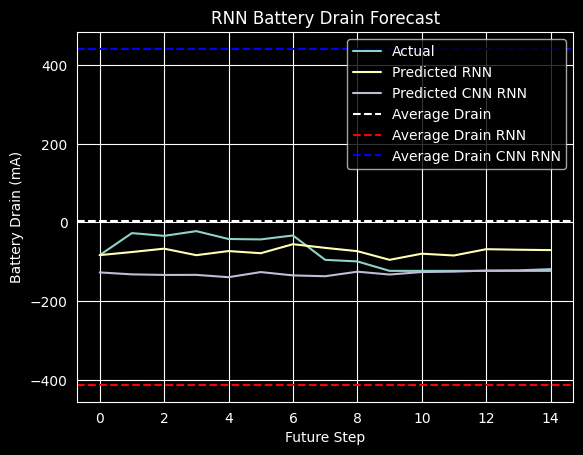

In [22]:
avg_rnn = np.mean(pred_rnn_real)
avg_cnn_rnn = np.mean(pred_cnn_rnn_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_rnn_real[idx], label="Predicted RNN")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_rnn, linestyle='--', label="Average Drain RNN", color="red")
plt.axhline(avg_cnn_rnn, linestyle='--', label="Average Drain CNN RNN", color="blue")
plt.title("RNN Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

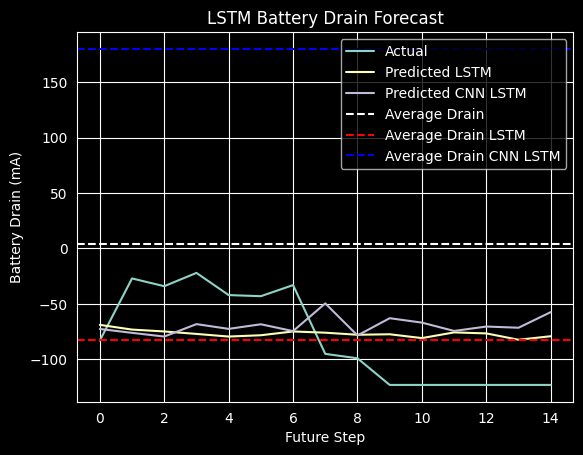

In [23]:
avg_lstm = np.mean(pred_lstm_real)
avg_cnn_lstm = np.mean(pred_cnn_lstm_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_lstm_real[idx], label="Predicted LSTM")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_lstm, linestyle='--', label="Average Drain LSTM", color="red")
plt.axhline(avg_cnn_lstm, linestyle='--', label="Average Drain CNN LSTM", color="blue")
plt.title("LSTM Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

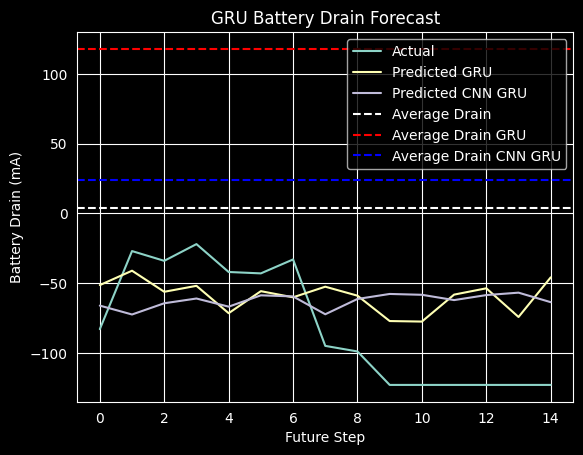

In [24]:
avg_gru = np.mean(pred_gru_real)
avg_cnn_gru = np.mean(pred_cnn_gru_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_gru_real[idx], label="Predicted GRU")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_gru, linestyle='--', label="Average Drain GRU", color="red")
plt.axhline(avg_cnn_gru, linestyle='--', label="Average Drain CNN GRU", color="blue")
plt.title("GRU Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

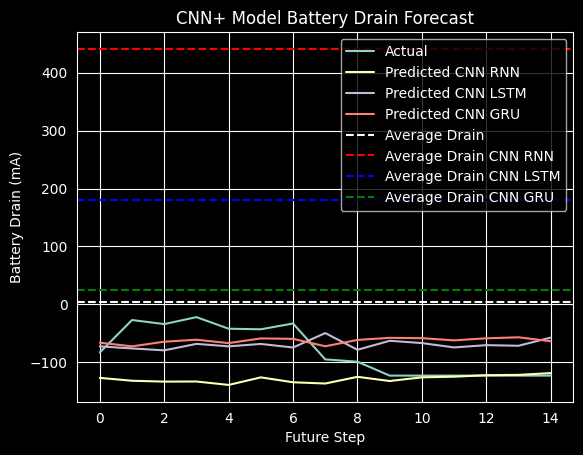

In [25]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_cnn_rnn, linestyle='--', label="Average Drain CNN RNN", color="red")
plt.axhline(avg_cnn_lstm, linestyle='--', label="Average Drain CNN LSTM", color="blue")
plt.axhline(avg_cnn_gru, linestyle='--', label="Average Drain CNN GRU", color="green")
plt.title("CNN+ Model Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()